# Fake News Detection - Multi-Model NLP Pipeline

Comparing 4 text classification models (Logistic Regression, Naive Bayes, Random Forest, LinearSVC) using TF-IDF features on the Fake & Real News dataset.

- **Label 0** = Fake
- **Label 1** = Real

## 1. Imports & Setup

In [25]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import shap
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110})

os.makedirs('models', exist_ok=True)
os.makedirs('plots',  exist_ok=True)

## 2. Load & Merge Data

In [4]:
fake = pd.read_csv('/home/ad.rapidops.com/sneh.patel/Desktop/fake_news_detector/data/Fake.csv')
true = pd.read_csv('/home/ad.rapidops.com/sneh.patel/Desktop/fake_news_detector/data/True.csv')

fake['label'] = 0
true['label'] = 1

df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Total samples : {len(df):,}')
print(f'Fake          : {(df.label==0).sum():,}')
print(f'Real          : {(df.label==1).sum():,}')
print(f'Columns       : {list(df.columns)}')
df.head(3)

Total samples : 44,898
Fake          : 23,481
Real          : 21,417
Columns       : ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1


In [5]:
print(df.info())
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB
None


title      0
text       0
subject    0
date       0
label      0
dtype: int64

## 3. Exploratory Data Analysis

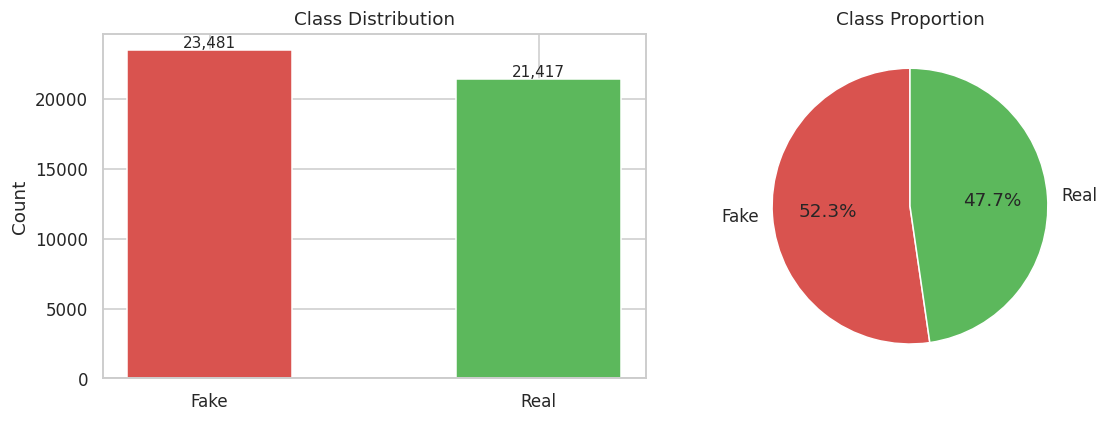

In [6]:
# Class distribution
label_counts = df['label'].value_counts().rename({0: 'Fake', 1: 'Real'})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(label_counts.index, label_counts.values, color=['#d9534f', '#5cb85c'], width=0.5)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 150, f'{v:,}', ha='center', fontsize=10)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(label_counts.values, labels=label_counts.index,
            colors=['#d9534f', '#5cb85c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('plots/01_class_distribution.png', bbox_inches='tight')
plt.show()

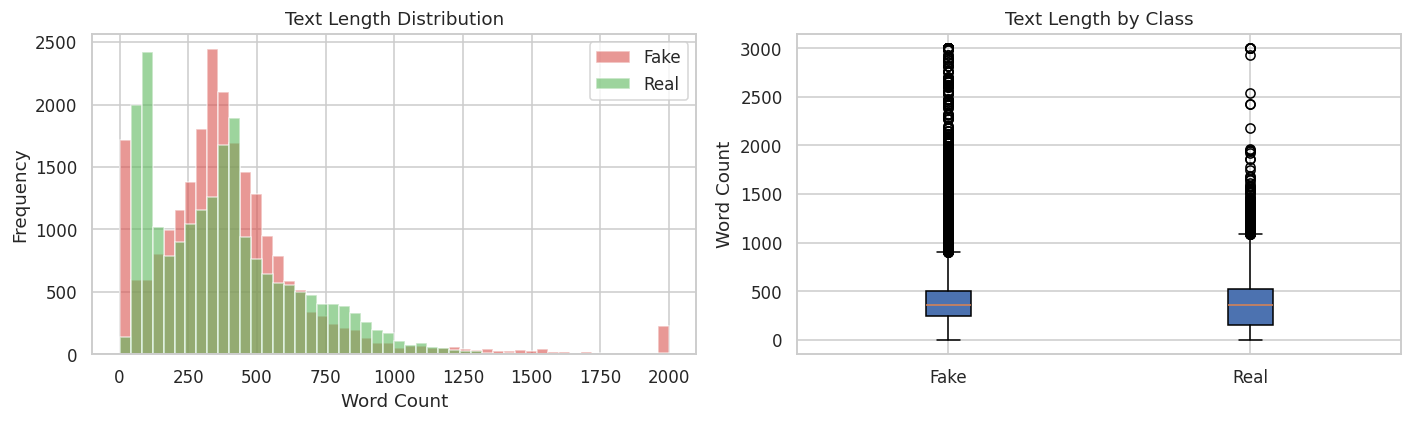

In [7]:
# Text length distribution
df['text_length'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label_val, label_name, color in [(0, 'Fake', '#d9534f'), (1, 'Real', '#5cb85c')]:
    axes[0].hist(df[df['label']==label_val]['text_length'].clip(upper=2000),
                 bins=50, alpha=0.6, label=label_name, color=color)
axes[0].set_title('Text Length Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(
    [df[df['label']==0]['text_length'].clip(upper=3000),
     df[df['label']==1]['text_length'].clip(upper=3000)],
    labels=['Fake', 'Real'], patch_artist=True
)
axes[1].set_title('Text Length by Class')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('plots/02_text_length.png', bbox_inches='tight')
plt.show()

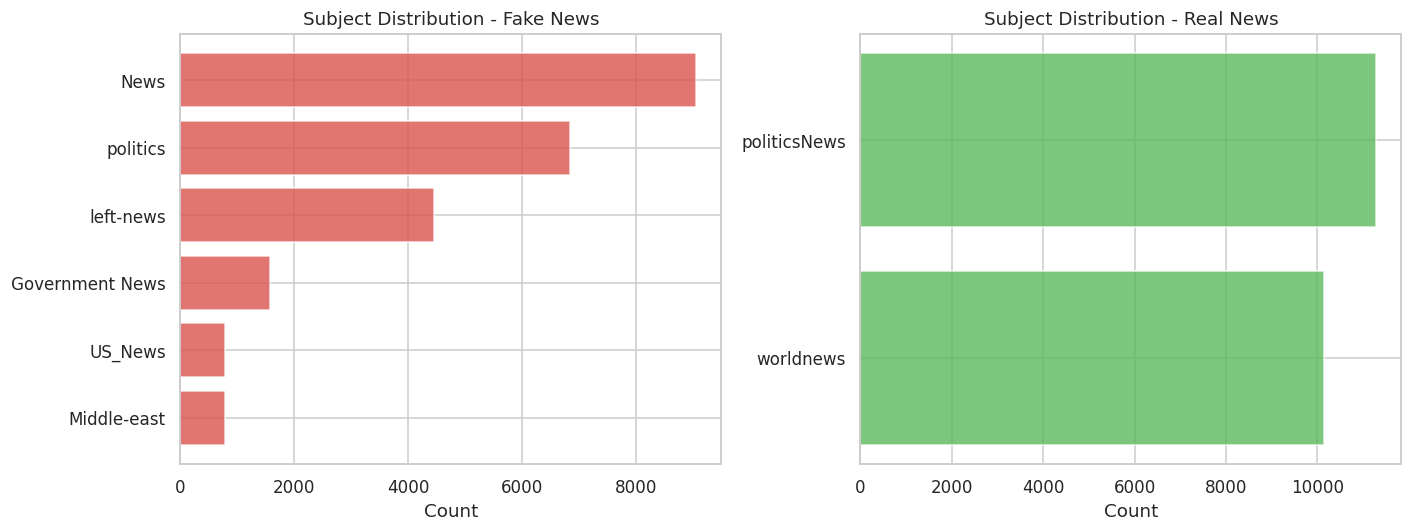

In [8]:
# Subject distribution per class
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, label_val, label_name, color in [
    (axes[0], 0, 'Fake News', '#d9534f'),
    (axes[1], 1, 'Real News', '#5cb85c')
]:
    counts = df[df['label']==label_val]['subject'].value_counts().head(8)
    ax.barh(counts.index[::-1], counts.values[::-1], color=color, alpha=0.8)
    ax.set_title(f'Subject Distribution - {label_name}')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.savefig('plots/03_subject_distribution.png', bbox_inches='tight')
plt.show()

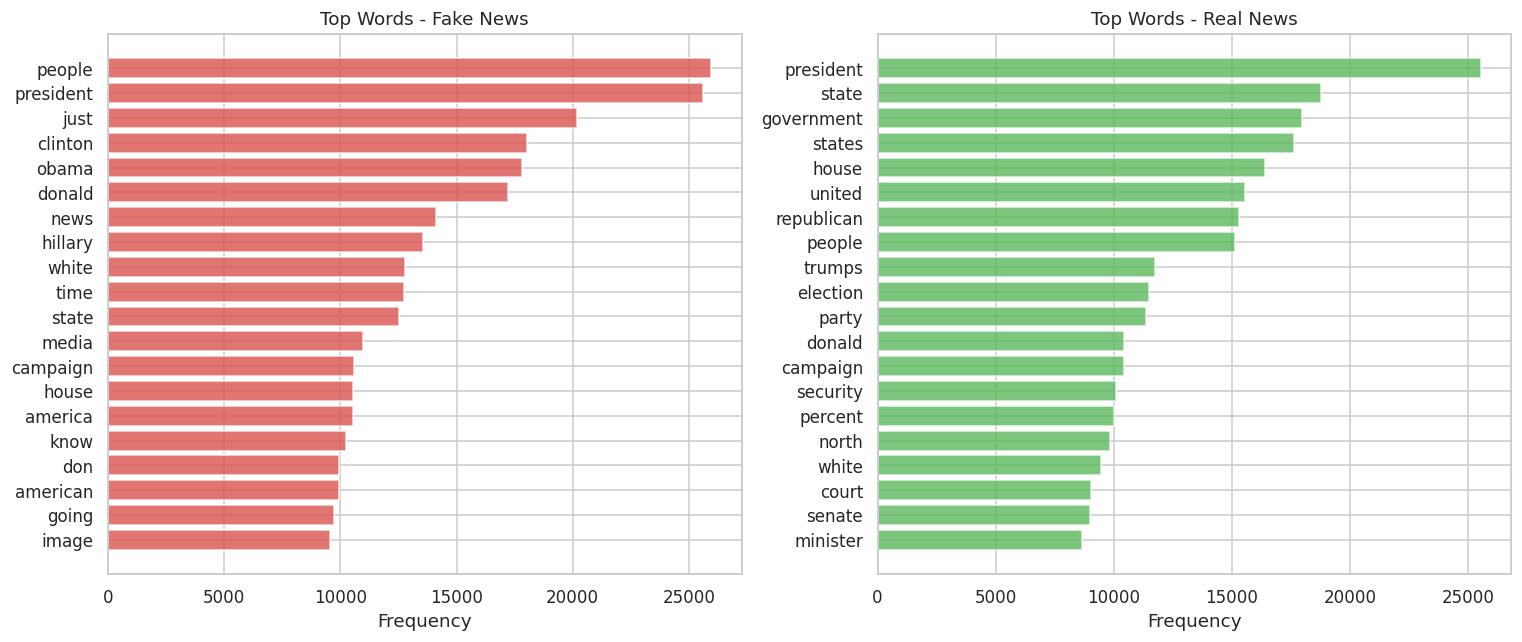

In [9]:
# Top words per class
EXTRA_STOPS = {'said', 'would', 'also', 'one', 'new', 'year',
               'reuters', 'washington', 'us', 'u', 'trump', 'like', 'told'}
ALL_STOPS = ENGLISH_STOP_WORDS.union(EXTRA_STOPS)

def top_words(texts, n=20):
    words = [
        w for text in texts
        for w in re.sub(r'[^a-z\s]', '', str(text).lower()).split()
        if w not in ALL_STOPS and len(w) > 2
    ]
    return Counter(words).most_common(n)

fake_words = top_words(df[df['label']==0]['text'])
real_words = top_words(df[df['label']==1]['text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, word_counts, title, color in [
    (axes[0], fake_words, 'Top Words - Fake News', '#d9534f'),
    (axes[1], real_words, 'Top Words - Real News', '#5cb85c')
]:
    words, counts = zip(*word_counts)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('plots/04_top_words.png', bbox_inches='tight')
plt.show()

## 4. Text Preprocessing

In [10]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(preprocess_text)

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Train: 35,918 | Test: 8,980


## 5. Model Pipelines

In [11]:
TFIDF_PARAMS = dict(
    stop_words='english',
    max_df=0.85,
    min_df=3,
    ngram_range=(1, 2),
    max_features=100_000
)

models = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   MultinomialNB(alpha=0.1))
    ]),
    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42))
    ]),
    'LinearSVC': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LinearSVC(C=1.0, max_iter=2000, random_state=42))
    ])
}

In [13]:
results = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if name == 'LinearSVC':
        y_score = 1 / (1 + np.exp(-pipeline.decision_function(X_test)))
    else:
        y_score = pipeline.predict_proba(X_test)[:, 1]

    results[name] = {
        'pipeline': pipeline,
        'y_pred':   y_pred,
        'y_score':  y_score,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, y_score),
        'report':   classification_report(y_test, y_pred, output_dict=True),
        'cm':       confusion_matrix(y_test, y_pred)
    }

## 6. Model Evaluation & Comparison

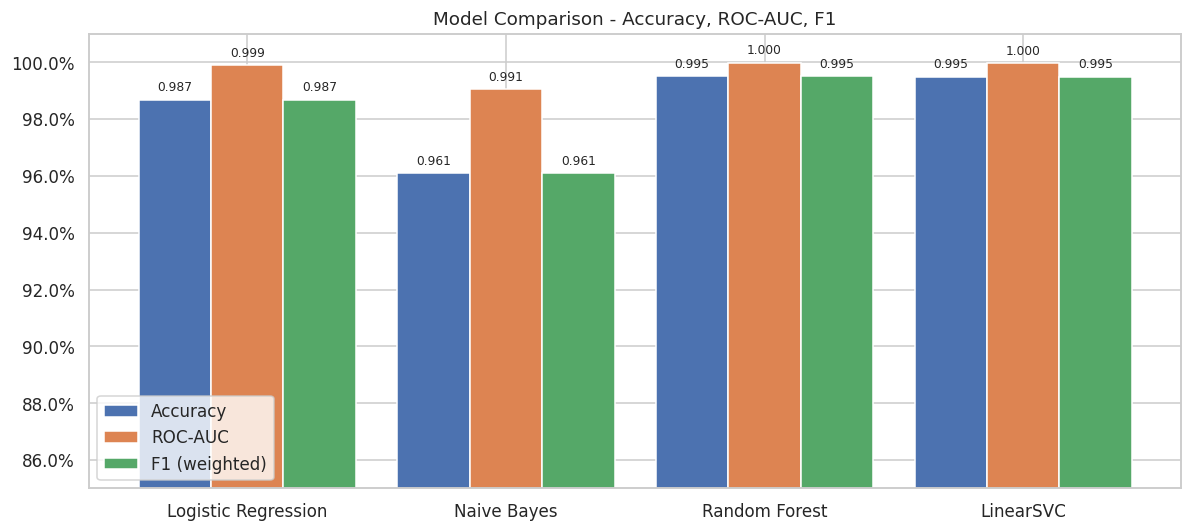

In [14]:
# Accuracy, ROC-AUC, F1 comparison
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
roc_aucs    = [results[m]['roc_auc']  for m in model_names]
f1_scores   = [results[m]['report']['weighted avg']['f1-score'] for m in model_names]

x = np.arange(len(model_names))
width = 0.28

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width, accuracies, width, label='Accuracy')
b2 = ax.bar(x,         roc_aucs,   width, label='ROC-AUC')
b3 = ax.bar(x + width, f1_scores,  width, label='F1 (weighted)')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0.85, 1.01)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Model Comparison - Accuracy, ROC-AUC, F1')
ax.legend()

plt.tight_layout()
plt.savefig('plots/05_model_comparison.png', bbox_inches='tight')
plt.show()

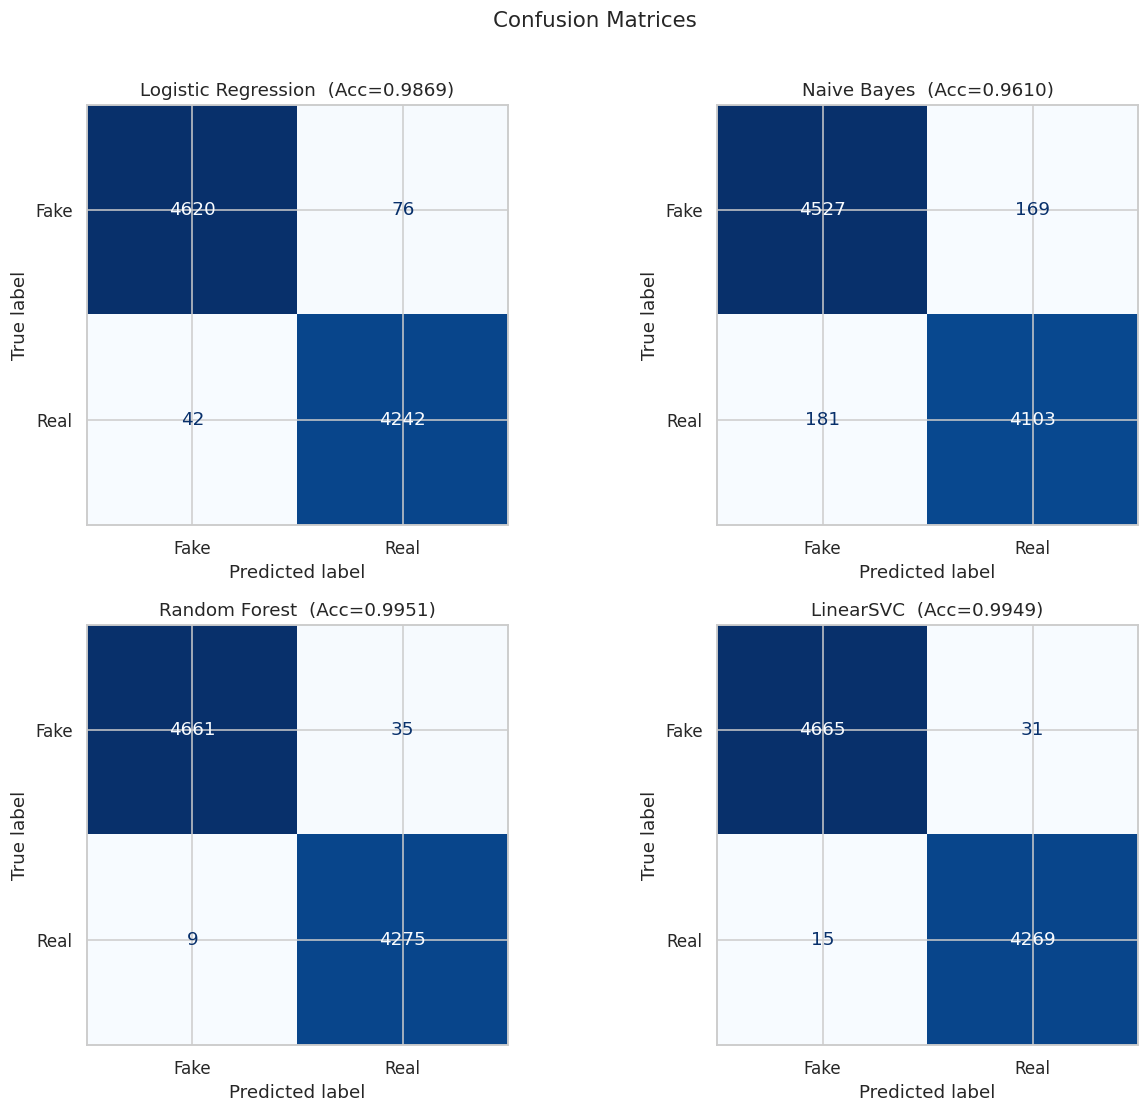

In [15]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    disp = ConfusionMatrixDisplay(res['cm'], display_labels=['Fake', 'Real'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{name}  (Acc={res["accuracy"]:.4f})')

plt.suptitle('Confusion Matrices', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/06_confusion_matrices.png', bbox_inches='tight')
plt.show()

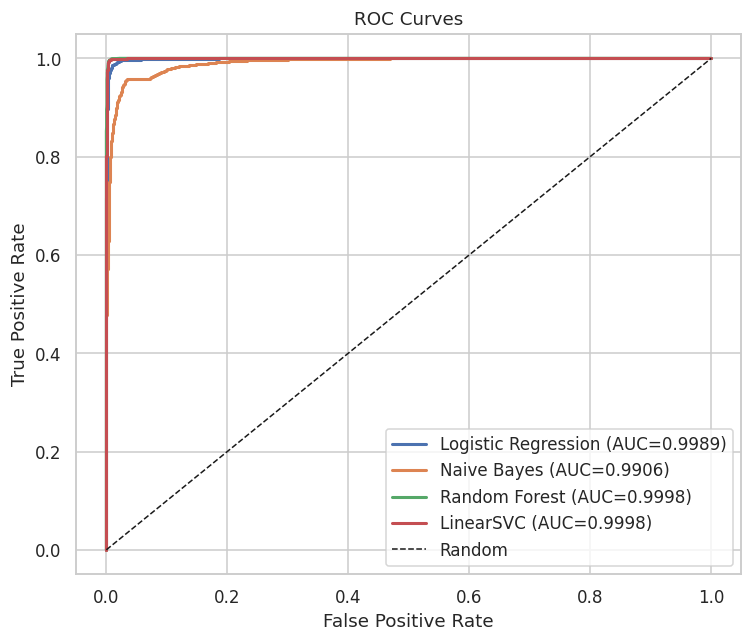

In [18]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_score'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={res["roc_auc"]:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('plots/07_roc_curves.png', bbox_inches='tight')
plt.show()

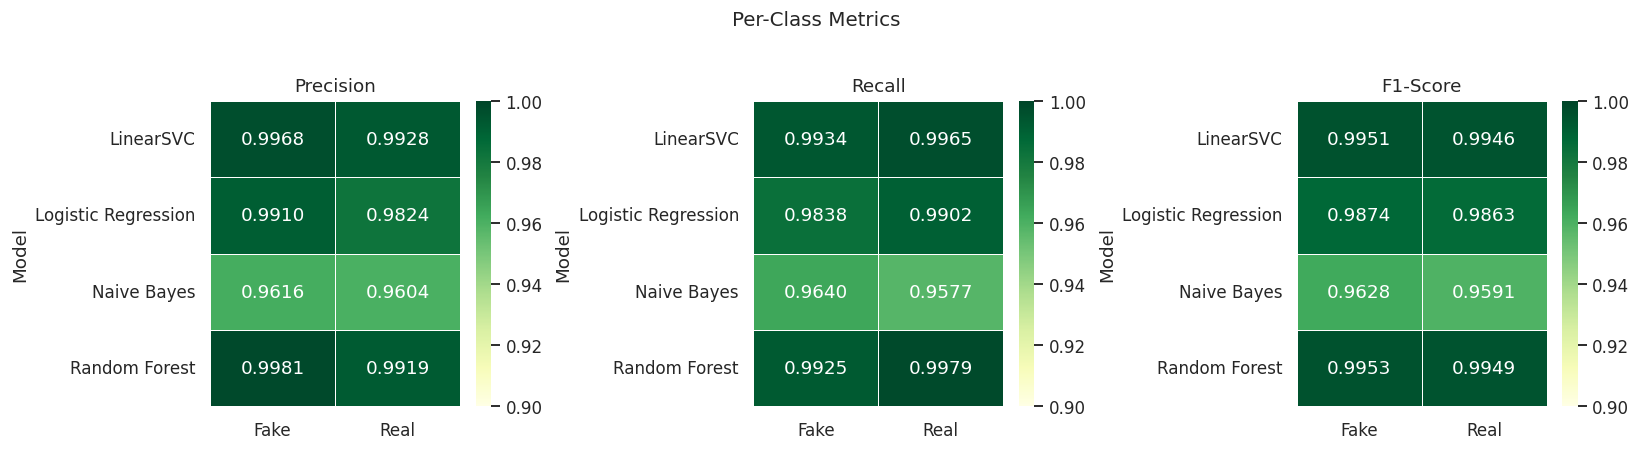

In [19]:
# Per-class precision, recall, F1 heatmap
metrics_rows = []
for name, res in results.items():
    for cls, cls_name in [(0, 'Fake'), (1, 'Real')]:
        r = res['report'][str(cls)]
        metrics_rows.append({
            'Model': name, 'Class': cls_name,
            'Precision': r['precision'],
            'Recall':    r['recall'],
            'F1-Score':  r['f1-score']
        })

metrics_df = pd.DataFrame(metrics_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['Precision', 'Recall', 'F1-Score']):
    pivot = metrics_df.pivot(index='Model', columns='Class', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
                ax=ax, vmin=0.9, vmax=1.0, linewidths=0.5)
    ax.set_title(metric)
    ax.set_xlabel('')

plt.suptitle('Per-Class Metrics', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('plots/08_class_metrics_heatmap.png', bbox_inches='tight')
plt.show()

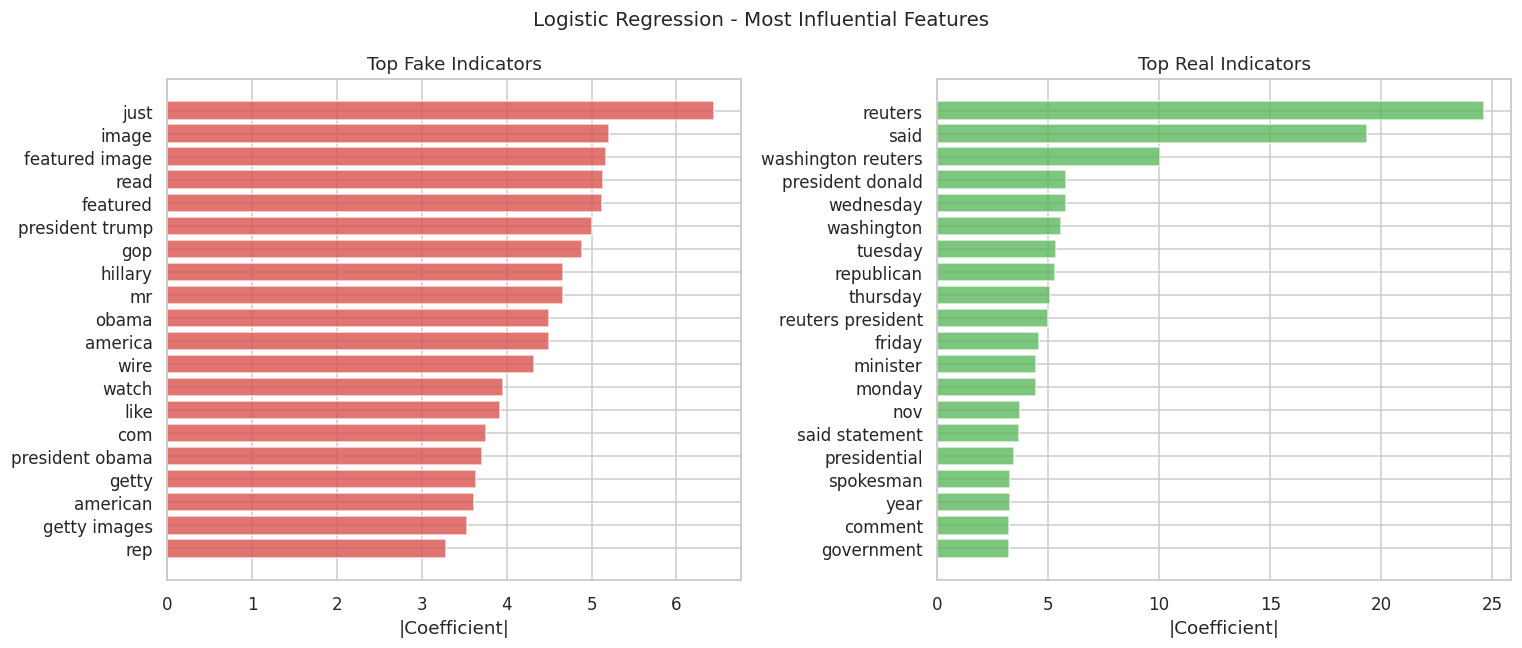

In [20]:
# Top features from Logistic Regression coefficients
lr_pipeline   = results['Logistic Regression']['pipeline']
tfidf_vec     = lr_pipeline.named_steps['tfidf']
lr_clf        = lr_pipeline.named_steps['clf']
feature_names = np.array(tfidf_vec.get_feature_names_out())
coef          = lr_clf.coef_[0]

top_n = 20
top_fake_idx = np.argsort(coef)[:top_n]
top_real_idx = np.argsort(coef)[-top_n:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, idxs, title, color in [
    (axes[0], top_fake_idx, 'Top Fake Indicators', '#d9534f'),
    (axes[1], top_real_idx, 'Top Real Indicators', '#5cb85c')
]:
    words  = feature_names[idxs]
    scores = np.abs(coef[idxs])
    ax.barh(words[::-1], scores[::-1], color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('|Coefficient|')

plt.suptitle('Logistic Regression - Most Influential Features', fontsize=13)
plt.tight_layout()
plt.savefig('plots/09_feature_importance.png', bbox_inches='tight')
plt.show()

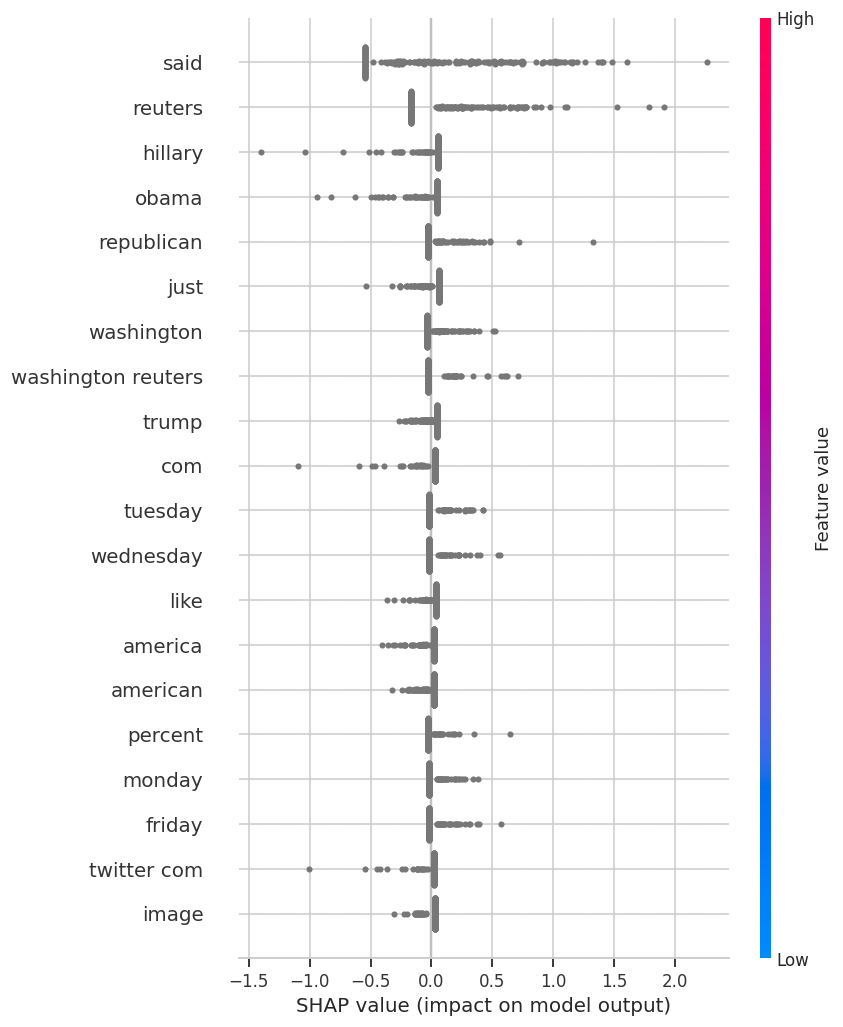

In [30]:
import shap

tfidf     = models['Logistic Regression'].named_steps['tfidf']
lr        = models['Logistic Regression'].named_steps['clf']

X_train_tfidf = tfidf.transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

explainer   = shap.LinearExplainer(lr, X_train_tfidf)
shap_values = explainer.shap_values(X_test_tfidf[:200])

shap.summary_plot(
    shap_values,
    X_test_tfidf[:200],
    feature_names=tfidf.get_feature_names_out(),
    show=False
)
plt.tight_layout()
plt.savefig('plots/08_shap_summary.png', bbox_inches='tight')
plt.show()

## 7. Save Models

In [21]:
# Summary table
summary = pd.DataFrame([
    {
        'Model':            name,
        'Accuracy':         round(res['accuracy'], 4),
        'ROC-AUC':          round(res['roc_auc'], 4),
        'F1 (weighted)':    round(res['report']['weighted avg']['f1-score'], 4),
        'Precision (Fake)': round(res['report']['0']['precision'], 4),
        'Recall (Fake)':    round(res['report']['0']['recall'], 4),
    }
    for name, res in results.items()
])

best_model_name = max(results, key=lambda m: results[m]['roc_auc'])
print(f'Best model: {best_model_name}')
summary

Best model: Random Forest


,Model,Accuracy,ROC-AUC,F1 (weighted),Precision (Fake),Recall (Fake)
0,Logistic Regression,0.9869,0.9989,0.9869,0.9910,0.9838
1,Naive Bayes,0.9610,0.9906,0.9610,0.9616,0.9640
2,Random Forest,0.9951,0.9998,0.9951,0.9981,0.9925
3,LinearSVC,0.9949,0.9998,0.9949,0.9968,0.9934


In [22]:
# Save each model pipeline
for name, res in results.items():
    path = 'models/' + name.lower().replace(' ', '_') + '_pipeline.pkl'
    joblib.dump(res['pipeline'], path)
    print(f'Saved: {path}')

# Save best model separately
joblib.dump(results[best_model_name]['pipeline'], 'models/best_model.pkl')
print(f'\nBest model ({best_model_name}) -> models/best_model.pkl')

Saved: models/logistic_regression_pipeline.pkl
Saved: models/naive_bayes_pipeline.pkl
Saved: models/random_forest_pipeline.pkl
Saved: models/linearsvc_pipeline.pkl

Best model (Random Forest) -> models/best_model.pkl


## 8. Inference Demo

In [23]:
loaded_model = joblib.load('models/best_model.pkl')

samples = [
    "Scientists confirm that drinking coffee every day prevents all forms of cancer.",
    "The Federal Reserve raised interest rates by 25 basis points to combat inflation.",
    "Breaking: Celebrities paid $10M to fake moon landing photos leaked online.",
    "Congress passed a bipartisan infrastructure bill to rebuild roads and bridges."
]

predictions = loaded_model.predict(samples)

for text, pred in zip(samples, predictions):
    label = 'REAL' if pred == 1 else 'FAKE'
    print(f'[{label}] {text[:80]}')

[FAKE] Scientists confirm that drinking coffee every day prevents all forms of cancer.
[FAKE] The Federal Reserve raised interest rates by 25 basis points to combat inflation
[FAKE] Breaking: Celebrities paid $10M to fake moon landing photos leaked online.
[FAKE] Congress passed a bipartisan infrastructure bill to rebuild roads and bridges.
